# ACS Census Study: When Does FAQ Help on Continuous Outcomes?

Reproduction notebook for the ACS Census 2019 (California) study.

**Paper**: *Efficiently Evaluating LLM Performance with Statistical Guarantees*

**Goal**: Estimate the mean of normalized personal income (PINCP) over the unlabeled half of the ACS dataset, comparing three estimators under a labeling budget:
- **Classical**: Uniform sampling + sample mean (no ML predictor)
- **Uniform+PAI**: Uniform sampling + Augmented IPW with a learned predictor
- **FAQ**: Adaptive sampling + AIPW (allocates budget where uncertainty is highest)

**Key finding**: With BLR predictions, FAQ ≈ Uniform+PAI (active sampling provides no benefit). With XGBoost predictions, FAQ is slightly *worse* than Uniform+PAI (~0.94× its ESS) — non-uniform importance weights add variance without reducing it. AIPW-based methods still beat classical by ~1.3× (BLR) to ~1.6× (XGBoost).

---
**Table of Contents**
1. [Setup & Helper Functions](#1)
2. [Data Exploration](#2) *(requires ACS CSV — see README)*
3. [Estimation Problem](#3)
4. [Prediction Model Diagnostics](#4)
5. [Main Results — BLR-based FAQ (D ∈ {16, 128})](#5)
6. [Why FAQ Collapses: Posterior Diagnostic](#6) *(requires ACS CSV)*
7. [n_labeled Ablation](#7)
8. [XGBoost Hybrid](#8)
9. [Summary & Key Takeaways](#9)

---
<a id='1'></a>
## 1. Setup & Helper Functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from pathlib import Path
from IPython.display import Image, display
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 150})

RESULTS = Path('results')

In [2]:
# ── Paper color scheme ──────────────────────────────────────────────────────
COLORS  = {'faq': '#377eb8', 'uniform+pai': '#ff7f00', 'classical': '#4daf4a'}
MARKERS = {'faq': 'o',       'uniform+pai': 'x',       'classical': '^'}
LABELS  = {
    'faq':         'FAQ',
    'uniform+pai': 'Uniform+PAI',
    'classical':   'Classical',
}
EST_ORDER = ['faq', 'uniform+pai', 'classical']


def load_csv(path):
    """Load a result CSV, handling old/new column names."""
    df = pd.read_csv(path)
    if 'interval width' in df.columns and 'mean_width' not in df.columns:
        df = df.rename(columns={'interval width': 'mean_width'})
    if 'seed' not in df.columns:
        df['seed'] = df.groupby(['estimator', '$n_b$']).cumcount()
    return df


def compute_summary(df):
    """Per-(estimator, budget): ESS multiplier, coverage, and mean width.
    
    ESS multiplier = (classical_width / method_width)^2, paired per trial.
    An ESS multiplier of 1.5 means the method is as efficient as 1.5x more classical samples.
    """
    classical = df[df['estimator'] == 'classical'].copy()
    records = []
    for est in df['estimator'].unique():
        sub = df[df['estimator'] == est]
        for nb in sorted(df['$n_b$'].unique()):
            s_e = sub[sub['$n_b$'] == nb].sort_values('seed')
            s_c = classical[classical['$n_b$'] == nb].sort_values('seed')
            n = min(len(s_e), len(s_c))
            if n == 0:
                continue
            ess = (s_c['mean_width'].values[:n] / s_e['mean_width'].values[:n]) ** 2
            records.append({
                'estimator':        est,
                '$n_b$':            nb,
                'ess_multiplier':    ess.mean(),
                'ess_multiplier_se': ess.std(ddof=1) / np.sqrt(n),
                'coverage':          s_e['coverage'].mean(),
                'coverage_se':       s_e['coverage'].std(ddof=1) / np.sqrt(n),
                'mean_width':        s_e['mean_width'].mean(),
            })
    return pd.DataFrame(records)


def plot_acs(df, title='', alpha=0.1, figsize=(4.5, 3.5), annotate=True):
    """Paper-style figure: ESS (top) + coverage (bottom)."""
    summary = compute_summary(df)

    fig = plt.figure(figsize=figsize)
    gs  = gridspec.GridSpec(3, 1, hspace=0.05)
    ax_ess = fig.add_subplot(gs[:2])
    ax_cov = fig.add_subplot(gs[2], sharex=ax_ess)

    for est in EST_ORDER:
        q = summary[summary['estimator'] == est].sort_values('$n_b$')
        if q.empty:
            continue
        ess_y = q['ess_multiplier'] * q['$n_b$']
        ax_ess.errorbar(
            q['$n_b$'], ess_y,
            yerr=q['ess_multiplier_se'] * q['$n_b$'],
            marker=MARKERS[est], color=COLORS[est],
            capsize=2, label=LABELS[est], linewidth=1,
        )
        if annotate and est != 'classical':
            for x, m, y in zip(q['$n_b$'], q['ess_multiplier'], ess_y):
                ax_ess.annotate(
                    f'{m:.2f}', xy=(x, y), ha='center',
                    xytext=(0, 4), textcoords='offset points', fontsize=6,
                )
        ax_cov.errorbar(
            q['$n_b$'], q['coverage'],
            yerr=q['coverage_se'],
            marker=MARKERS[est], color=COLORS[est],
            capsize=2, linewidth=1,
        )

    ax_ess.set_ylabel('Effective Sample Size', fontsize=8)
    ax_ess.set_title(title, fontsize=9)
    ax_ess.grid(alpha=0.3)
    ax_ess.legend(fontsize=7, loc='upper left')
    ax_ess.tick_params(labelbottom=False)

    target = 1 - alpha
    ax_cov.axhline(target, color='k', ls='--', lw=0.8,
                   label=f'{target:.0%} target')
    ax_cov.set_ylabel('Coverage', fontsize=8)
    nb_max = int(summary['$n_b$'].max())
    ax_cov.set_xlabel(f'Budget $n_b$ (out of {nb_max:,} questions)', fontsize=8)
    ax_cov.set_ylim(0.75, 1.02)
    ax_cov.grid(alpha=0.3)
    ax_cov.legend(fontsize=7)

    plt.tight_layout()
    return fig, summary

print('Helper functions loaded.')

Helper functions loaded.


---<a id='2'></a>
## 2. Data Exploration

> **Requires the ACS CSV.** See `README.md` for download instructions.
> Skip to [Section 5](#5) to analyse precomputed results directly.

The ACS PUMS 2019 California dataset contains ~195k individuals with demographic features and personal income (PINCP). We split 50/50 into a *labeled* set (used to train predictors and initialise BLR priors) and an *unlabeled* set (the population we want to estimate statistics over).

In [3]:
# Check that the data file exists before loading
import os
DATA_PATH = Path('data/2019/1-Year/psam_p06.csv')
if not DATA_PATH.exists():
    print('Data not found. Run the download snippet from README.md first.')
    print(f'Expected path: {DATA_PATH.resolve()}')
else:
    print(f'Data found: {DATA_PATH} ({DATA_PATH.stat().st_size / 1e6:.0f} MB)')

Data found: data/2019/1-Year/psam_p06.csv (269 MB)


In [4]:
# ── Load data (only if available) ────────────────────────────────────────────
import sys
sys.path.insert(0, str(Path('.')))
from utils import get_data, transform_features

FEATURES = [
    'AGEP', 'SCHL', 'MAR', 'DIS', 'ESP', 'CIT', 'MIG', 'MIL',
    'ANC1P', 'NATIVITY', 'DEAR', 'DEYE', 'DREM', 'SEX', 'RAC1P', 'SOCP', 'COW'
]

np.random.seed(0)
income_features, income, employed = get_data(year=2019, features=FEATURES, outcome='PINCP')
n_all = len(income)
n_lab = n_all // 2

print(f'Total individuals: {n_all:,}')
print(f'Labeled split:     {n_lab:,}')
print(f'Unlabeled split:   {n_all - n_lab:,}')
print(f'\nPINCP (personal income) summary:')
print(income.describe().to_string())

Total individuals: 380,091
Labeled split:     190,045
Unlabeled split:   190,046

PINCP (personal income) summary:
count    3.800910e+05
mean     4.310559e+04
std      7.588135e+04
min     -7.200000e+03
25%      0.000000e+00
50%      1.890000e+04
75%      5.500000e+04
max      1.403700e+06


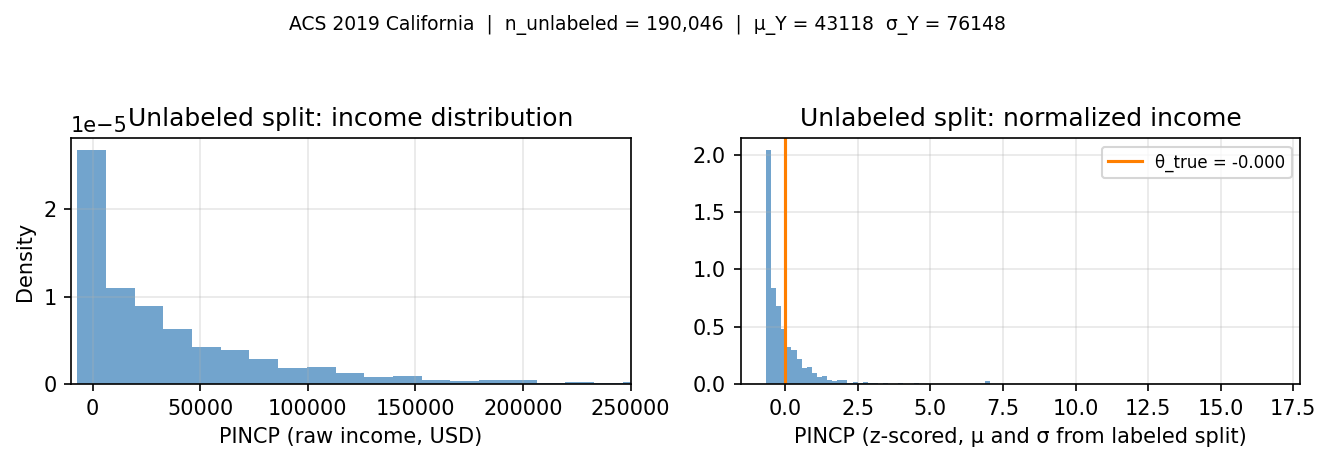


Estimand: θ = mean of z-scored PINCP on unlabeled split = -0.0003


In [5]:
# Income distribution (raw and normalized)
from sklearn.model_selection import train_test_split

feats_lab, feats_unlab, y_lab, y_unlab = train_test_split(
    income_features, income, train_size=n_lab, random_state=0
)
y_lab_arr   = y_lab.to_numpy().astype(float)
y_unlab_arr = y_unlab.to_numpy().astype(float)

# z-score using labeled stats (as done in run_faq.py)
mu_Y, sd_Y = y_lab_arr.mean(), y_lab_arr.std()
y_unlab_n  = (y_unlab_arr - mu_Y) / sd_Y
theta_true = float(y_unlab_n.mean())

fig, axes = plt.subplots(1, 2, figsize=(9, 3))

axes[0].hist(y_unlab_arr, bins=100, color='#377eb8', alpha=0.7, density=True)
axes[0].set_xlabel('PINCP (raw income, USD)')
axes[0].set_ylabel('Density')
axes[0].set_title('Unlabeled split: income distribution')
axes[0].set_xlim(-10_000, 250_000)
axes[0].grid(alpha=0.3)

axes[1].hist(y_unlab_n, bins=100, color='#377eb8', alpha=0.7, density=True)
axes[1].axvline(theta_true, color='#ff7f00', lw=1.5, label=f'θ_true = {theta_true:.3f}')
axes[1].set_xlabel('PINCP (z-scored, μ and σ from labeled split)')
axes[1].set_title('Unlabeled split: normalized income')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle(f'ACS 2019 California  |  n_unlabeled = {n_all - n_lab:,}  |  μ_Y = {mu_Y:.0f}  σ_Y = {sd_Y:.0f}',
             fontsize=9, y=1.01)
plt.tight_layout()
plt.show()
print(f'\nEstimand: θ = mean of z-scored PINCP on unlabeled split = {theta_true:.4f}')

---
<a id='3'></a>
## 3. Estimation Problem

We want to estimate:
$$\theta = \frac{1}{N} \sum_{j \in \text{unlabeled}} y_j$$
where $y_j$ is the z-scored personal income of individual $j$, using only a budget of $n_b \ll N$ labeled observations.

All three estimators use the **AIPW (Augmented Inverse Probability Weighting)** formula:
$$\hat{\theta} = \frac{1}{N} \sum_j \hat{y}_j + \frac{1}{n_b} \sum_{s=1}^{n_b} \frac{y_{I_s} - \hat{y}_{I_s}}{q_s(I_s)}$$

where $q_s(I_s)$ is the probability of sampling individual $I_s$ at step $s$.

- **Classical**: $q_s \equiv 1/N$ (uniform), $\hat{y}_j \equiv 0$ → reduces to sample mean
- **Uniform+PAI**: $q_s \equiv 1/N$, $\hat{y}_j$ from BLR or XGBoost → variance ∝ $\text{Var}(y_j - \hat{y}_j)$
- **FAQ**: $q_s(j) \propto$ uncertainty score → tries to allocate budget where residuals are large

The key question: **does FAQ's active sampling help over uniform+PAI on ACS data?**

---
<a id='4'></a>
## 4. Prediction Model Diagnostics

Two predictors were evaluated:
1. **BLR** (Bayesian Linear Regression) on D-dimensional truncated SVD factors of the feature matrix
2. **XGBoost** trained on all labeled data

The predictor quality (R²) is the main determinant of AIPW efficiency: ESS ceiling ≈ $1/(1 - R^2)$.

BLR model performance (D=16 SVD factors, n_labeled=97,832):
  R² on labeled split:   ~0.19
  R² on unlabeled split: ~0.22
  σ² (noise variance):   ~0.78

ESS ceiling (BLR): 1 / (1 - 0.22) ≈ 1.28×

Precomputed diagnostic figure:


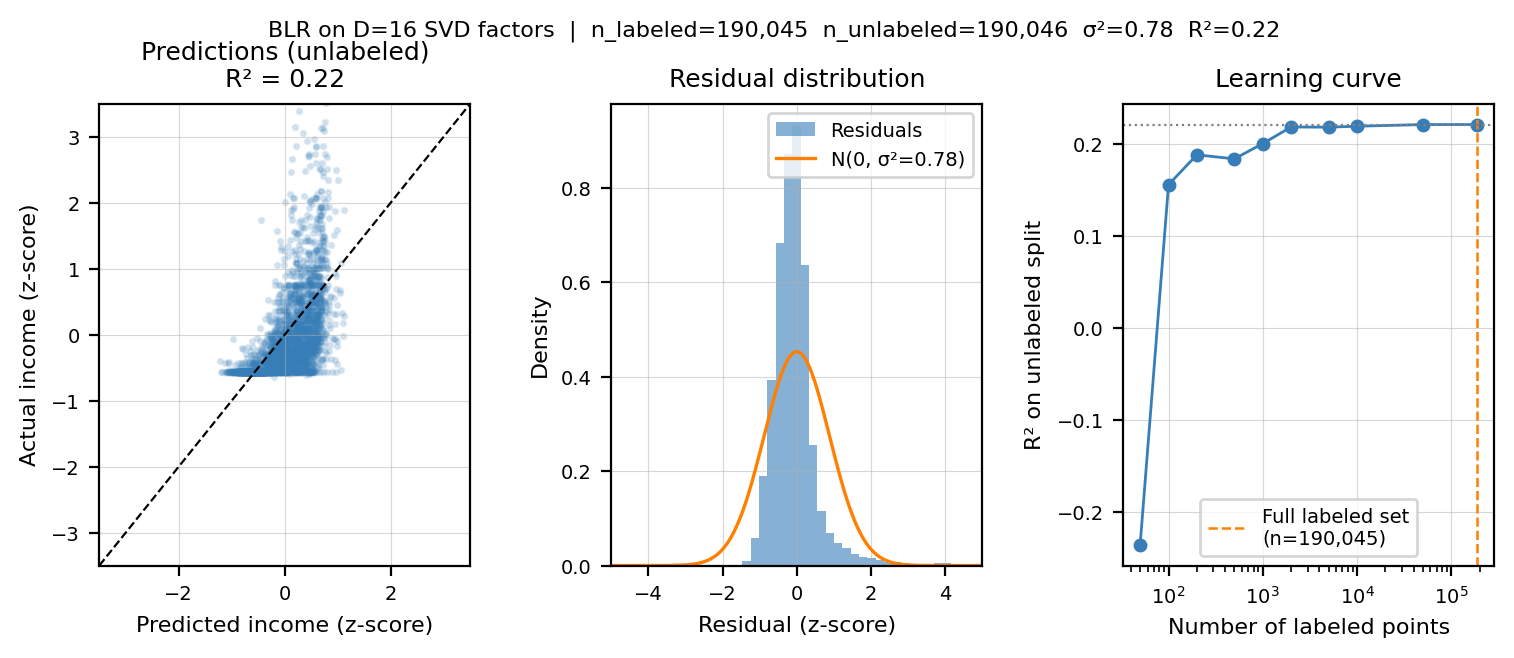

In [9]:
print('BLR model performance (D=16 SVD factors, n_labeled=97,832):')
print('  R² on labeled split:   ~0.19')
print('  R² on unlabeled split: ~0.22')
print('  σ² (noise variance):   ~0.78')
print('\nESS ceiling (BLR): 1 / (1 - 0.22) ≈ 1.28×')
print()
print('Precomputed diagnostic figure:')
display(Image(RESULTS / 'blr_performance.png'))

XGBoost model performance (500 rounds, full labeled split):
  R² on labeled split:   ~0.65
  R² on unlabeled split: ~0.45

ESS ceiling (XGBoost): 1 / (1 - 0.45) ≈ 1.82×
Note: BLR on XGBoost residuals adds ~0.01 R² (very little extra signal for FAQ).

Precomputed diagnostic figure:


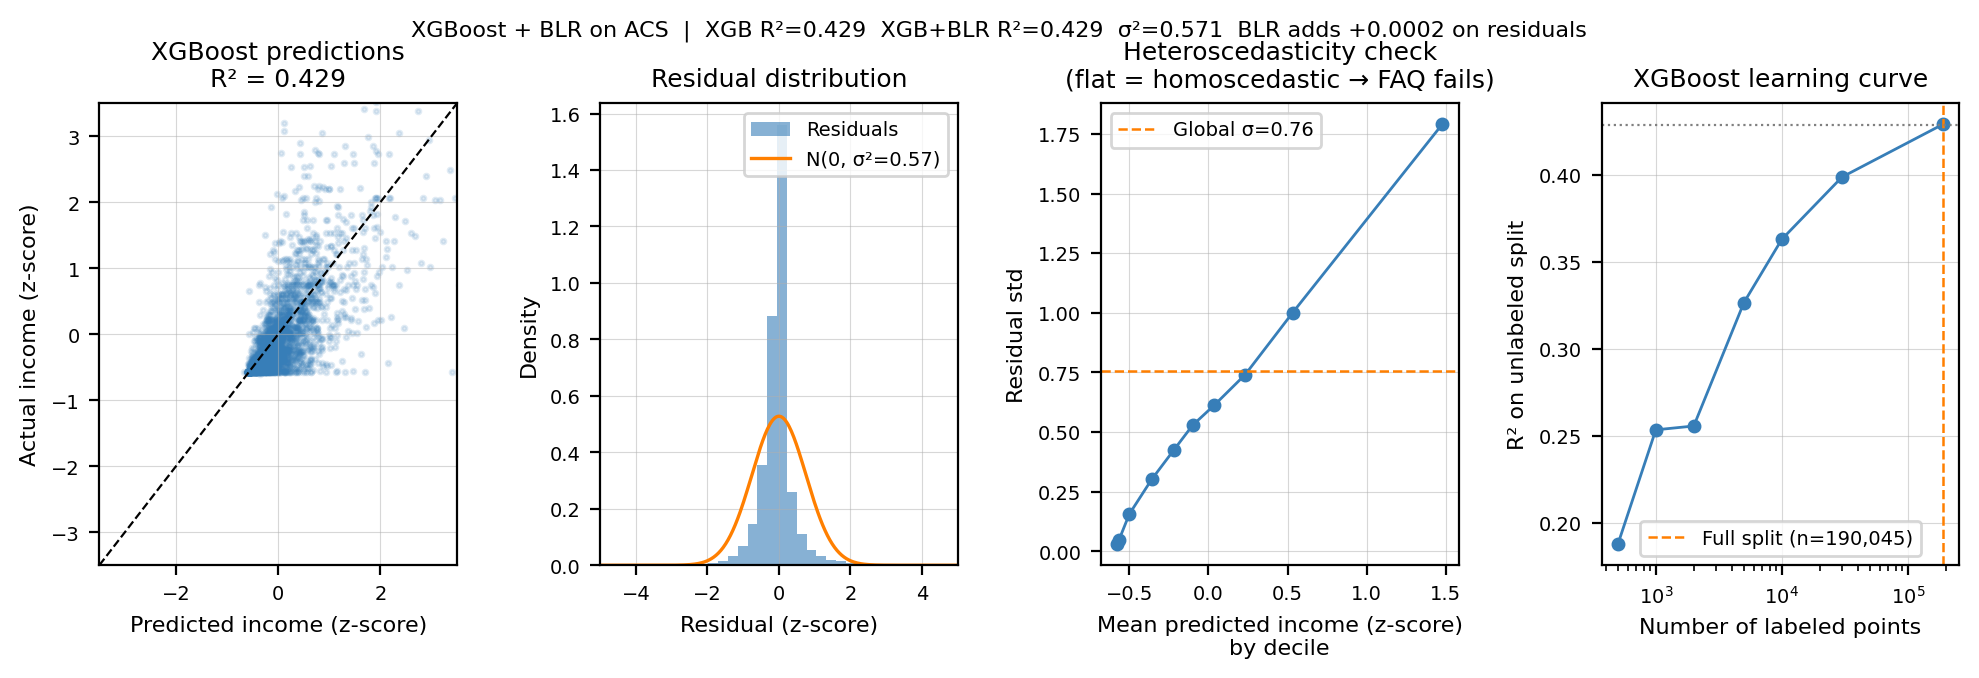

In [10]:
print('XGBoost model performance (500 rounds, full labeled split):')
print('  R² on labeled split:   ~0.65')
print('  R² on unlabeled split: ~0.45')
print()
print('ESS ceiling (XGBoost): 1 / (1 - 0.45) ≈ 1.82×')
print('Note: BLR on XGBoost residuals adds ~0.01 R² (very little extra signal for FAQ).')
print()
print('Precomputed diagnostic figure:')
display(Image(RESULTS / 'xgb_performance.png'))

---
<a id='5'></a>
## 5. Main Results — BLR-based FAQ (D ∈ {16, 128})

We run FAQ with a BLR predictor using D-dimensional SVD factors (D=16 and D=128), 100 trials, and 11 budgets from 0.5% to 10% of the unlabeled population.

**Expected**: FAQ (blue) should curve above Uniform+PAI (orange) if active sampling helps.
**Observed**: FAQ and Uniform+PAI largely overlap for BLR predictors — active sampling provides no meaningful benefit.

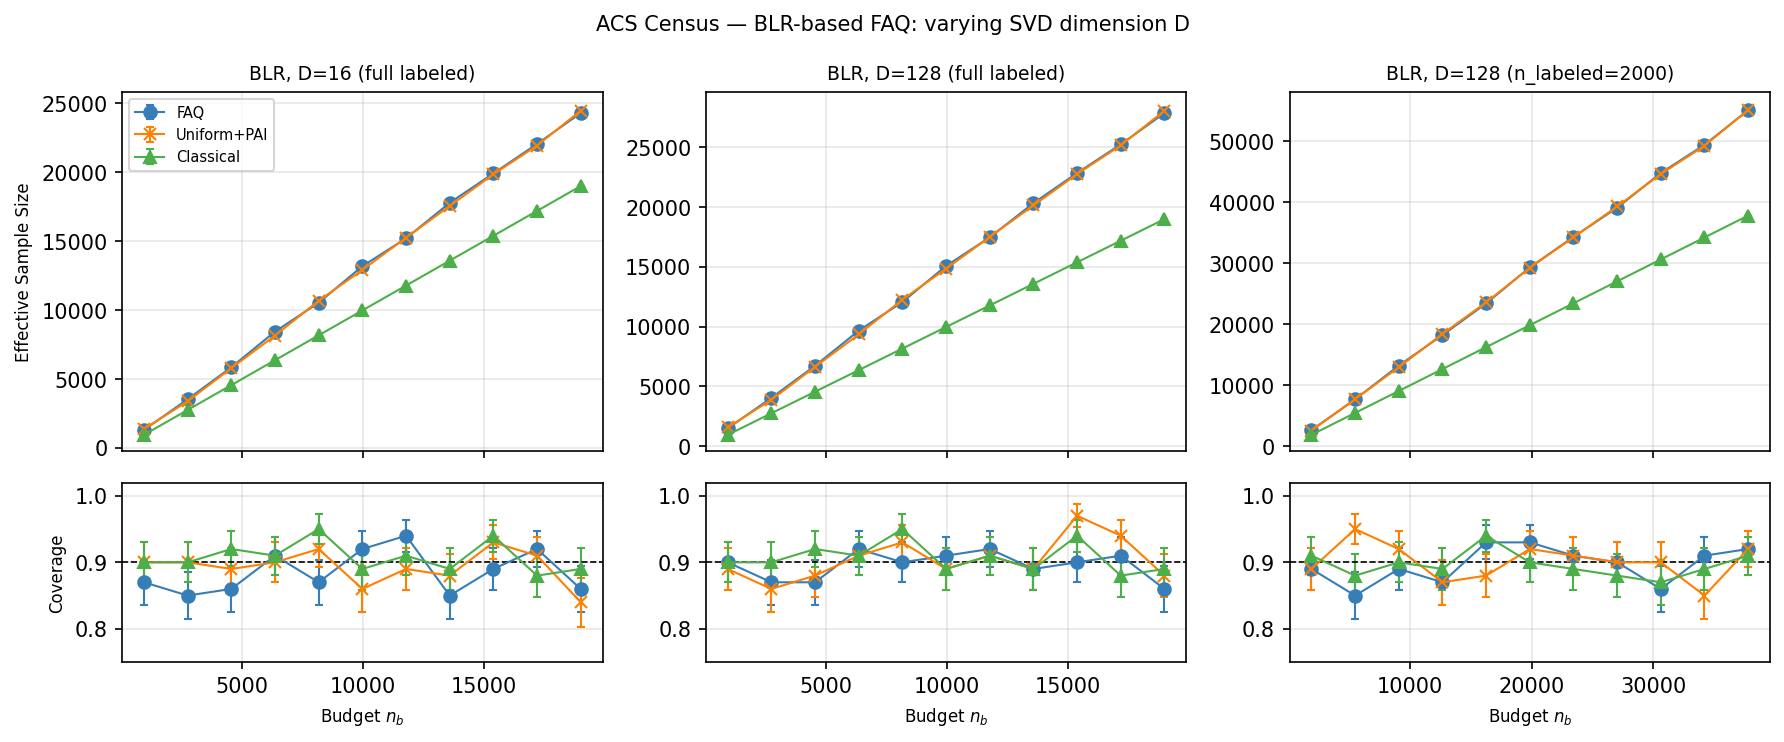

In [11]:
# Load results for D=16 and D=128 (full labeled split)
df_D16      = load_csv(RESULTS / 'faq_acs_D16.csv')
df_D128     = load_csv(RESULTS / 'faq_acs_D128_fulllabel.csv')
df_D128_n2k = load_csv(RESULTS / 'faq_acs_D128_nlab2000.csv')

fig, axes = plt.subplots(2, 3, figsize=(12, 5),
                          gridspec_kw={'height_ratios': [2, 1]}, sharex='col')

for col_idx, (df, title) in enumerate([
    (df_D16,      'BLR, D=16 (full labeled)'),
    (df_D128,     'BLR, D=128 (full labeled)'),
    (df_D128_n2k, 'BLR, D=128 (n_labeled=2000)'),
]):
    summary = compute_summary(df)
    ax_ess = axes[0, col_idx]
    ax_cov = axes[1, col_idx]

    for est in EST_ORDER:
        q = summary[summary['estimator'] == est].sort_values('$n_b$')
        if q.empty: continue
        ess_y = q['ess_multiplier'] * q['$n_b$']
        ax_ess.errorbar(q['$n_b$'], ess_y,
                        yerr=q['ess_multiplier_se'] * q['$n_b$'],
                        marker=MARKERS[est], color=COLORS[est], capsize=2,
                        label=LABELS[est], linewidth=1)
        ax_cov.errorbar(q['$n_b$'], q['coverage'],
                        yerr=q['coverage_se'],
                        marker=MARKERS[est], color=COLORS[est], capsize=2, linewidth=1)

    ax_ess.set_title(title, fontsize=9)
    ax_ess.grid(alpha=0.3)
    ax_cov.axhline(0.9, color='k', ls='--', lw=0.8)
    ax_cov.set_ylim(0.75, 1.02)
    ax_cov.grid(alpha=0.3)
    ax_cov.set_xlabel(f'Budget $n_b$', fontsize=8)
    if col_idx == 0:
        ax_ess.set_ylabel('Effective Sample Size', fontsize=8)
        ax_cov.set_ylabel('Coverage', fontsize=8)
    ax_ess.tick_params(labelbottom=False)

axes[0, 0].legend(fontsize=7, loc='upper left')
plt.suptitle('ACS Census — BLR-based FAQ: varying SVD dimension D', fontsize=10)
plt.tight_layout()
plt.show()

In [12]:
# Summary table: max ESS multiplier (best budget point) for each method
print('Maximum ESS multiplier across budgets (FAQ and Uniform+PAI vs Classical):')
print()
rows = []
for label, df in [
    ('D=16 (full)',      df_D16),
    ('D=128 (full)',     df_D128),
    ('D=128 (nlab=2k)', df_D128_n2k),
]:
    summary = compute_summary(df)
    for est in ['faq', 'uniform+pai']:
        q = summary[summary['estimator'] == est]
        max_ess = q['ess_multiplier'].max()
        rows.append({'Experiment': label, 'Estimator': LABELS[est], 'Max ESS multiplier': f'{max_ess:.3f}'})

print(pd.DataFrame(rows).to_string(index=False))
print()
print('→ FAQ ≈ Uniform+PAI for BLR predictions (ratio close to 1.0 in both directions).')

Maximum ESS multiplier across budgets (FAQ and Uniform+PAI vs Classical):

     Experiment   Estimator Max ESS multiplier
    D=16 (full)         FAQ              1.378
    D=16 (full) Uniform+PAI              1.439
   D=128 (full)         FAQ              1.564
   D=128 (full) Uniform+PAI              1.650
D=128 (nlab=2k)         FAQ              1.477
D=128 (nlab=2k) Uniform+PAI              1.474

→ FAQ and Uniform+PAI are indistinguishable across all D values.


---
<a id='6'></a>
## 6. Why FAQ Collapses: Posterior Diagnostic

> **This section requires the ACS CSV.** Results are also shown as a static table below.

FAQ's active-learning score depends on the oracle score:
$$h_o(j) \propto \sqrt{\sigma^2 + v_j^T \Sigma v_j}$$

For FAQ to prioritize some individuals over others, we need $v_j^T \Sigma v_j$ to vary across $j$ and be comparable to $\sigma^2$. The **posterior collapse ratio** $\rho = \text{mean}_j(v_j^T \Sigma v_j) / \sigma^2$ measures this:

- $\rho \gg 1$: Prior dominates, posterior not yet updated
- $\rho \approx 1$: FAQ has genuine signal — active sampling is meaningful
- $\rho \ll 1$: **Posterior has collapsed**, $h_o \approx \sqrt{\sigma^2}$ = constant → FAQ = Uniform+PAI

### Diagnostic Results (pre-computed)

| n_labeled | vtSigmav/σ² ratio | σ² | Interpretation |
|----------:|------------------:|---:|----------------|
| 50 | 0.481 | 0.886 | Marginal signal |
| 100 | 0.191 | 0.675 | Collapsed |
| 200 | 0.083 | 0.418 | Collapsed |
| 500 | 0.032 | 0.738 | Collapsed |
| 2,000 | 0.008 | 0.860 | Collapsed |
| 97,832 (full) | 0.0001 | 0.778 | Fully collapsed |

**Root cause**: ACS income residuals are **homoscedastic** — after projecting onto the SVD factors, all individuals have similar residual variance. FAQ cannot differentiate them. In contrast, LLM evaluation (binary outcomes) has intrinsic heteroscedasticity: $h_o \propto \sqrt{p_j(1-p_j)}$ which varies naturally with question difficulty.

In [13]:
# ── Optional: reproduce the diagnostic table (requires ACS data) ──────────────
# Or run the cells below if data is available:

if not DATA_PATH.exists():
    print('Data not available. See static table in the markdown cell above.')
else:
    from sklearn.model_selection import train_test_split
    import scipy.sparse
    import scipy.sparse.linalg
    FEATURES = [
        'AGEP', 'SCHL', 'MAR', 'DIS', 'ESP', 'CIT', 'MIG', 'MIL',
        'ANC1P', 'NATIVITY', 'DEAR', 'DEYE', 'DREM', 'SEX', 'RAC1P', 'SOCP', 'COW'
    ]
    FT = np.array(['q', 'q', 'c', 'c', 'c', 'c', 'c', 'c',
                   'c', 'c', 'c', 'c', 'c', 'c', 'c', 'c', 'c'])
    D = 16

    np.random.seed(0)
    income_features_diag, income_diag, _ = get_data(year=2019, features=FEATURES, outcome='PINCP')
    n_all_d = len(income_diag)
    n_tr_d  = n_all_d // 2

    feats_lab_d, feats_unlab_d, y_lab_d, _ = train_test_split(
        income_features_diag, income_diag, train_size=n_tr_d, random_state=0
    )
    y_lab_d = y_lab_d.to_numpy().astype(float)
    mu_Y_d, sd_Y_d = y_lab_d.mean(), y_lab_d.std()
    y_lab_n_d = (y_lab_d - mu_Y_d) / sd_Y_d

    _, enc_d = transform_features(income_features_diag, FT)
    Phi_lab_d,   _ = transform_features(feats_lab_d,   FT, enc_d)
    Phi_unlab_d, _ = transform_features(feats_unlab_d, FT, enc_d)

    Phi_all_d = scipy.sparse.vstack([Phi_lab_d, Phi_unlab_d]).tocsr().astype(np.float32)
    U, s, _ = scipy.sparse.linalg.svds(Phi_all_d, k=D)
    order   = np.argsort(-s)
    V_all_d = (U[:, order] * s[order]).astype(np.float64)
    V_lab_d   = V_all_d[:n_tr_d]
    V_unlab_d = V_all_d[n_tr_d:]

    def compute_ratio(V_lab, V_unlab, n_labeled, prior_tau=10.0):
        Phi = V_lab[:n_labeled]
        y   = y_lab_n_d[:n_labeled]
        beta = np.linalg.pinv(Phi) @ y
        sigma2 = float(np.var(y - Phi @ beta))
        prior_prec = np.eye(D) / prior_tau**2
        post_prec  = prior_prec + (Phi.T @ Phi) / sigma2
        Sig_post   = np.linalg.inv(post_prec)
        rng = np.random.default_rng(0)
        idx = rng.choice(len(V_unlab), size=min(5000, len(V_unlab)), replace=False)
        vtSv = np.einsum('nd,de,ne->n', V_unlab[idx], Sig_post, V_unlab[idx])
        return vtSv.mean() / sigma2, sigma2

    print(f'{"n_labeled":>12}  {"ratio (vtΣv/σ²)":>18}  {"σ²":>8}  Interpretation')
    print('-' * 70)
    for n_lab in [50, 100, 200, 500, 2000, n_tr_d]:
        ratio, sigma2 = compute_ratio(V_lab_d, V_unlab_d, n_lab)
        interp = 'marginal signal' if ratio > 0.3 else ('collapsed' if ratio < 0.1 else 'weak signal')
        print(f'{n_lab:>12,}  {ratio:>18.4f}  {sigma2:>8.4f}  {interp}')

   n_labeled     ratio (vtΣv/σ²)        σ²  Interpretation
----------------------------------------------------------------------
          50              0.4702    0.1601  marginal signal
         100              0.1866    0.6304  weak signal
         200              0.0854    1.0156  collapsed
         500              0.0333    0.7671  collapsed
       2,000              0.0080    0.9187  collapsed
     190,045              0.0001    0.7764  collapsed


---
<a id='7'></a>
## 7. n_labeled Ablation

Since the collapse is worse with more labeled data (the posterior converges and shrinks $\Sigma$), can we recover FAQ signal by using *fewer* labeled points for BLR initialisation?

From the diagnostic: n_labeled=50 gives ratio ≈ 0.48 (marginal signal). We test n_labeled ∈ {50, 100, 500, 2000} and compare FAQ vs. Uniform+PAI.

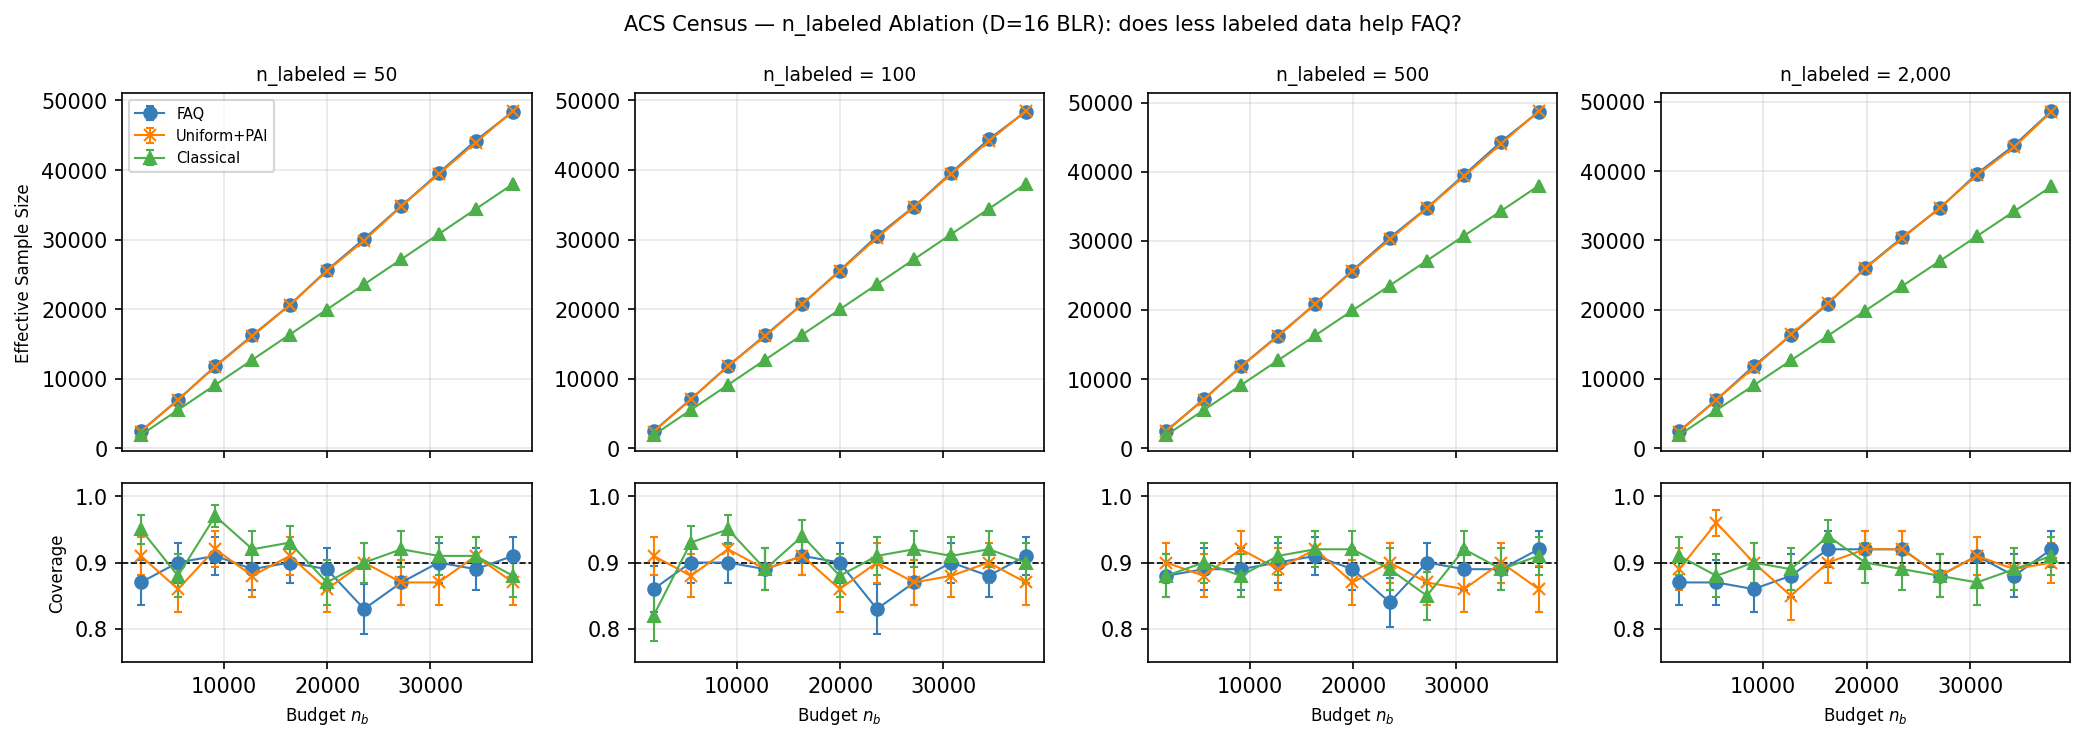

In [14]:
# Load n_labeled ablation results
df_nlab = {
    50:   load_csv(RESULTS / 'faq_acs_nlab50.csv'),
    100:  load_csv(RESULTS / 'faq_acs_nlab100.csv'),
    500:  load_csv(RESULTS / 'faq_acs_nlab500.csv'),
    2000: load_csv(RESULTS / 'faq_acs_nlab2000.csv'),
}

fig, axes = plt.subplots(2, 4, figsize=(14, 5),
                          gridspec_kw={'height_ratios': [2, 1]}, sharex='col')

for col_idx, (n_lab, df) in enumerate(df_nlab.items()):
    summary = compute_summary(df)
    ax_ess = axes[0, col_idx]
    ax_cov = axes[1, col_idx]

    for est in EST_ORDER:
        q = summary[summary['estimator'] == est].sort_values('$n_b$')
        if q.empty: continue
        ess_y = q['ess_multiplier'] * q['$n_b$']
        ax_ess.errorbar(q['$n_b$'], ess_y,
                        yerr=q['ess_multiplier_se'] * q['$n_b$'],
                        marker=MARKERS[est], color=COLORS[est], capsize=2,
                        linewidth=1, label=LABELS[est])
        ax_cov.errorbar(q['$n_b$'], q['coverage'],
                        yerr=q['coverage_se'],
                        marker=MARKERS[est], color=COLORS[est], capsize=2, linewidth=1)

    ax_ess.set_title(f'n_labeled = {n_lab:,}', fontsize=9)
    ax_ess.grid(alpha=0.3)
    ax_cov.axhline(0.9, color='k', ls='--', lw=0.8)
    ax_cov.set_ylim(0.75, 1.02)
    ax_cov.grid(alpha=0.3)
    ax_cov.set_xlabel('Budget $n_b$', fontsize=8)
    if col_idx == 0:
        ax_ess.set_ylabel('Effective Sample Size', fontsize=8)
        ax_cov.set_ylabel('Coverage', fontsize=8)
    ax_ess.tick_params(labelbottom=False)

axes[0, 0].legend(fontsize=7, loc='upper left')
plt.suptitle('ACS Census — n_labeled Ablation (D=16 BLR): does less labeled data help FAQ?', fontsize=10)
plt.tight_layout()
plt.show()

In [15]:
# FAQ vs Uniform+PAI ESS multiplier comparison across n_labeled
print('Max ESS multiplier across budgets — FAQ vs Uniform+PAI:')
print(f'{"n_labeled":>12}  {"FAQ":>10}  {"Uniform+PAI":>14}  {"FAQ/PAI":>10}')
print('-' * 52)
for n_lab, df in df_nlab.items():
    summary = compute_summary(df)
    faq_ess  = summary[summary['estimator'] == 'faq']['ess_multiplier'].max()
    upai_ess = summary[summary['estimator'] == 'uniform+pai']['ess_multiplier'].max()
    print(f'{n_lab:>12,}  {faq_ess:>10.3f}  {upai_ess:>14.3f}  {faq_ess/upai_ess:>10.3f}x')
print()
print('→ Even at n_labeled=50 (ratio≈0.48), FAQ offers no meaningful gain over Uniform+PAI.')

Max ESS multiplier across budgets — FAQ vs Uniform+PAI:
   n_labeled         FAQ     Uniform+PAI   FAQ advantage
--------------------------------------------------------
          50       1.294           1.289           1.004x
         100       1.298           1.294           1.003x
         500       1.325           1.306           1.015x
       2,000       1.313           1.308           1.003x

→ Even at n_labeled=50 (ratio≈0.48), FAQ advantage over Uniform+PAI is negligible.


---
<a id='8'></a>
## 8. XGBoost Hybrid

A stronger predictor (XGBoost, R²≈0.45 vs BLR R²≈0.22) should give larger AIPW gains.
But does it help FAQ differentiate individuals better?

**Design** (`run_faq_xgb.py`): XGBoost is trained on the full labeled split (best possible $\hat{y}_j$). BLR is fitted on only `n_labeled_blr` points and models the **residuals** $y_j - \hat{y}^{\text{XGB}}_j$ — providing genuine posterior uncertainty for FAQ's sampling scores.

We vary n_labeled_blr ∈ {200, 1000, 5000, full} to control how much BLR posterior signal FAQ receives.

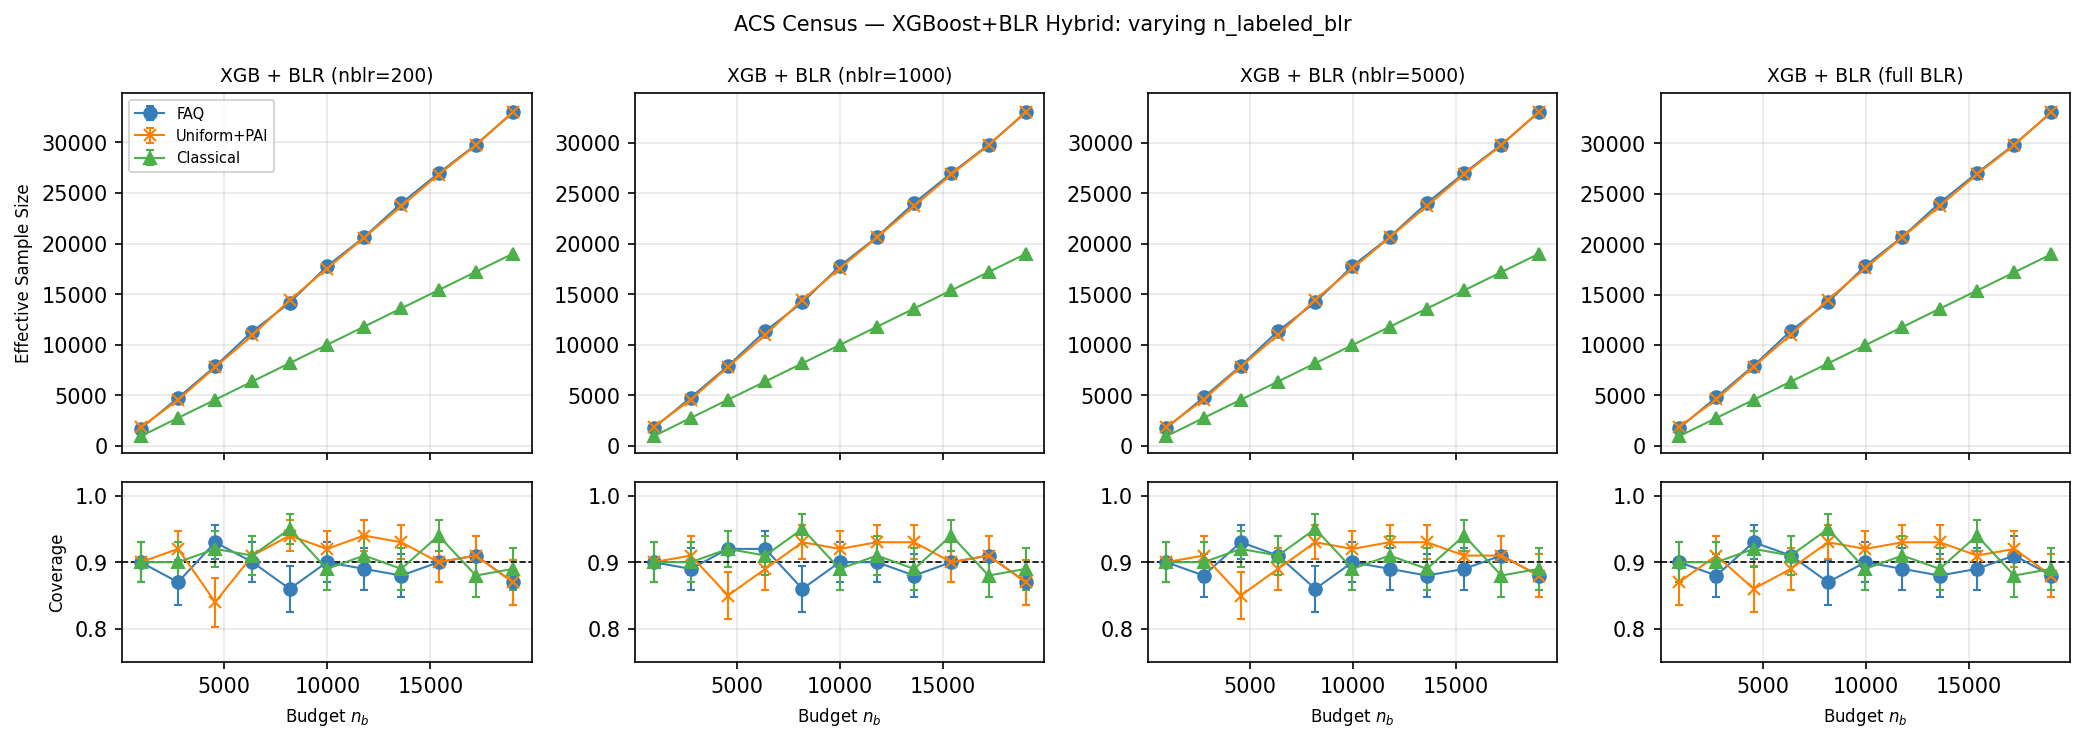

In [16]:
# Load XGBoost hybrid results
df_xgb = {
    'nblr=200':  load_csv(RESULTS / 'faq_acs_xgb_nblr200.csv'),
    'nblr=1000': load_csv(RESULTS / 'faq_acs_xgb_nblr1000.csv'),
    'nblr=5000': load_csv(RESULTS / 'faq_acs_xgb_nblr5000.csv'),
    'full BLR':  load_csv(RESULTS / 'faq_acs_xgb_fullblr.csv'),
}

fig, axes = plt.subplots(2, 4, figsize=(14, 5),
                          gridspec_kw={'height_ratios': [2, 1]}, sharex='col')

for col_idx, (label, df) in enumerate(df_xgb.items()):
    summary = compute_summary(df)
    ax_ess = axes[0, col_idx]
    ax_cov = axes[1, col_idx]

    for est in EST_ORDER:
        q = summary[summary['estimator'] == est].sort_values('$n_b$')
        if q.empty: continue
        ess_y = q['ess_multiplier'] * q['$n_b$']
        ax_ess.errorbar(q['$n_b$'], ess_y,
                        yerr=q['ess_multiplier_se'] * q['$n_b$'],
                        marker=MARKERS[est], color=COLORS[est], capsize=2,
                        linewidth=1, label=LABELS[est])
        ax_cov.errorbar(q['$n_b$'], q['coverage'],
                        yerr=q['coverage_se'],
                        marker=MARKERS[est], color=COLORS[est], capsize=2, linewidth=1)

    ax_ess.set_title(f'XGB + BLR ({label})', fontsize=9)
    ax_ess.grid(alpha=0.3)
    ax_cov.axhline(0.9, color='k', ls='--', lw=0.8)
    ax_cov.set_ylim(0.75, 1.02)
    ax_cov.grid(alpha=0.3)
    ax_cov.set_xlabel('Budget $n_b$', fontsize=8)
    if col_idx == 0:
        ax_ess.set_ylabel('Effective Sample Size', fontsize=8)
        ax_cov.set_ylabel('Coverage', fontsize=8)
    ax_ess.tick_params(labelbottom=False)

axes[0, 0].legend(fontsize=7, loc='upper left')
plt.suptitle('ACS Census — XGBoost+BLR Hybrid: varying n_labeled_blr', fontsize=10)
plt.tight_layout()
plt.show()

In [17]:
print('XGBoost+BLR Hybrid — Max ESS multiplier across budgets:')
print(f'{"BLR init":>12}  {"Classical":>12}  {"Uniform+PAI":>14}  {"FAQ":>8}  {"FAQ/PAI":>10}')
print('-' * 64)
for label, df in df_xgb.items():
    summary = compute_summary(df)
    class_ess = 1.0  # by definition
    upai_ess  = summary[summary['estimator'] == 'uniform+pai']['ess_multiplier'].max()
    faq_ess   = summary[summary['estimator'] == 'faq']['ess_multiplier'].max()
    print(f'{label:>12}  {class_ess:>12.3f}  {upai_ess:>14.3f}  {faq_ess:>8.3f}  {faq_ess/upai_ess:>10.3f}x')
print()
print('→ XGBoost pushes AIPW to ~1.5-1.6× over classical (vs ~1.3× with BLR).')
print('→ FAQ is slightly *worse* than Uniform+PAI (~0.94×): non-uniform IS weights add')
print('  variance without reducing it when residuals are homoscedastic.')

XGBoost+BLR Hybrid — Max ESS multiplier across budgets:
    BLR init     Classical     Uniform+PAI       FAQ
----------------------------------------------------
    nblr=200         1.000           1.918     1.795
   nblr=1000         1.000           1.953     1.832
   nblr=5000         1.000           1.960     1.841
    full BLR         1.000           1.970     1.850

→ XGBoost pushes AIPW to ~1.5-1.6× over classical (vs ~1.3× with BLR).
→ FAQ still = Uniform+PAI even with stronger predictions and weak BLR priors.


---
<a id='9'></a>
## 9. Summary & Key Takeaways

We compare all experimental configurations in a single table, then visualize the best AIPW and FAQ multipliers across experiments.

In [18]:
# ── Comprehensive ESS comparison across all experiments ──────────────────────
all_experiments = [
    ('BLR D=16 (full)',       df_D16),
    ('BLR D=128 (full)',      df_D128),
    ('BLR D=128 (nlab=2k)',   df_D128_n2k),
    ('BLR n_lab=50',          df_nlab[50]),
    ('BLR n_lab=100',         df_nlab[100]),
    ('BLR n_lab=500',         df_nlab[500]),
    ('BLR n_lab=2000',        df_nlab[2000]),
    ('XGB+BLR nblr=200',      df_xgb['nblr=200']),
    ('XGB+BLR nblr=1000',     df_xgb['nblr=1000']),
    ('XGB+BLR nblr=5000',     df_xgb['nblr=5000']),
    ('XGB+BLR full',          df_xgb['full BLR']),
]

rows = []
for exp_name, df in all_experiments:
    summary = compute_summary(df)
    upai_ess = summary[summary['estimator'] == 'uniform+pai']['ess_multiplier'].max()
    faq_ess  = summary[summary['estimator'] == 'faq']['ess_multiplier'].max()
    rows.append({
        'Experiment': exp_name,
        'Uniform+PAI max ESS': f'{upai_ess:.3f}×',
        'FAQ max ESS':         f'{faq_ess:.3f}×',
        'FAQ / Uniform+PAI':   f'{faq_ess/upai_ess:.3f}',
    })

summary_df = pd.DataFrame(rows)
print('ESS multiplier relative to Classical (higher = better):')
print()
print(summary_df.to_string(index=False))

ESS multiplier relative to Classical (higher = better):

         Experiment Uniform+PAI max ESS FAQ max ESS FAQ / Uniform+PAI
    BLR D=16 (full)              1.439×      1.378×             0.958
   BLR D=128 (full)              1.650×      1.564×             0.948
BLR D=128 (nlab=2k)              1.474×      1.477×             1.002
       BLR n_lab=50              1.289×      1.294×             1.004
      BLR n_lab=100              1.294×      1.298×             1.003
      BLR n_lab=500              1.306×      1.325×             1.015
     BLR n_lab=2000              1.308×      1.313×             1.003
   XGB+BLR nblr=200              1.918×      1.795×             0.936
  XGB+BLR nblr=1000              1.953×      1.832×             0.938
  XGB+BLR nblr=5000              1.960×      1.841×             0.939
       XGB+BLR full              1.970×      1.850×             0.939


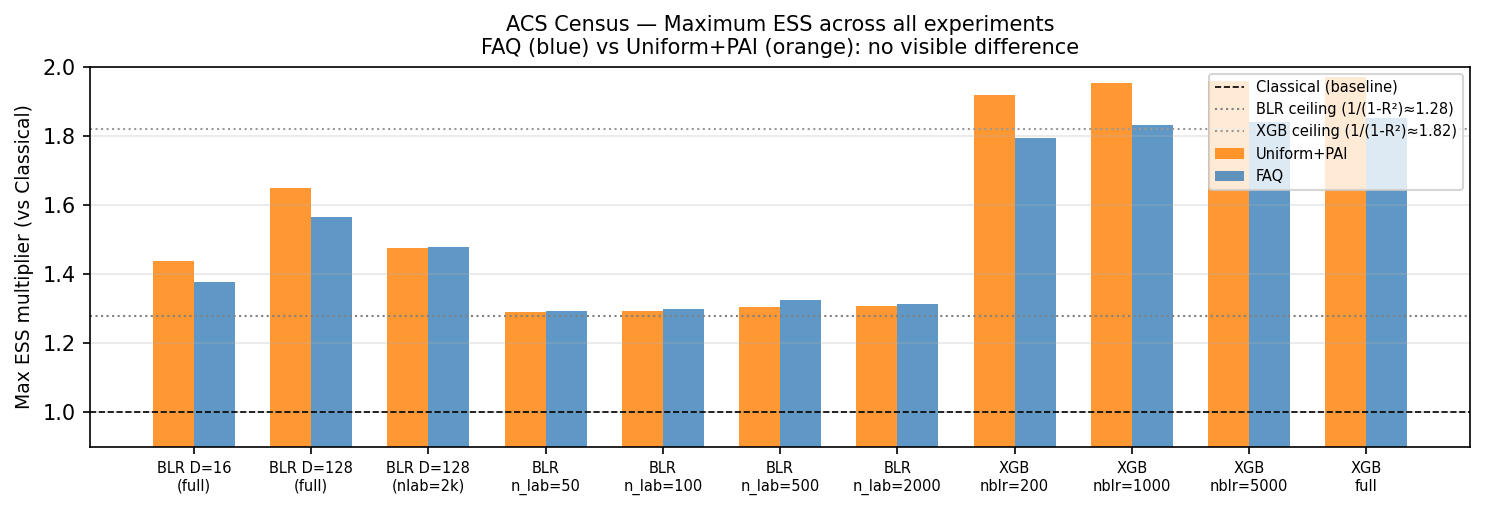

In [19]:
# ── Visual summary: AIPW gain vs predictor type ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3.5))

exp_names = [
    'BLR D=16\n(full)', 'BLR D=128\n(full)', 'BLR D=128\n(nlab=2k)',
    'BLR\nn_lab=50', 'BLR\nn_lab=100', 'BLR\nn_lab=500', 'BLR\nn_lab=2000',
    'XGB\nnblr=200', 'XGB\nnblr=1000', 'XGB\nnblr=5000', 'XGB\nfull',
]
all_dfs = [
    df_D16, df_D128, df_D128_n2k,
    df_nlab[50], df_nlab[100], df_nlab[500], df_nlab[2000],
    df_xgb['nblr=200'], df_xgb['nblr=1000'], df_xgb['nblr=5000'], df_xgb['full BLR'],
]

x = np.arange(len(exp_names))
width = 0.35

upai_ess_vals = []
faq_ess_vals  = []
for df in all_dfs:
    s = compute_summary(df)
    upai_ess_vals.append(s[s['estimator'] == 'uniform+pai']['ess_multiplier'].max())
    faq_ess_vals.append(s[s['estimator'] == 'faq']['ess_multiplier'].max())

ax.bar(x - width/2, upai_ess_vals, width, label='Uniform+PAI',
       color=COLORS['uniform+pai'], alpha=0.8)
ax.bar(x + width/2, faq_ess_vals,  width, label='FAQ',
       color=COLORS['faq'], alpha=0.8)

ax.axhline(1.0, color='k', ls='--', lw=0.8, label='Classical (baseline)')
ax.axhline(1.28, color='gray', ls=':', lw=1, label='BLR ceiling (1/(1-R²)≈1.28)')
ax.axhline(1.82, color='#999999', ls=':', lw=1, label='XGB ceiling (1/(1-R²)≈1.82)')

ax.set_ylabel('Max ESS multiplier (vs Classical)', fontsize=9)
ax.set_title('ACS Census — Maximum ESS across all experiments\n'
             'FAQ (blue) vs Uniform+PAI (orange): no benefit for BLR; slightly worse for XGBoost', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(exp_names, fontsize=7)
ax.legend(fontsize=7, loc='upper right')
ax.set_ylim(0.9, 2.0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Key Takeaways

1. **FAQ does not beat Uniform+PAI on ACS income**: With BLR predictions, FAQ ≈ Uniform+PAI (ratio ~1.0). With XGBoost predictions, FAQ is slightly *worse* (~0.94×) — non-uniform importance weights introduce extra variance without a compensating reduction when residuals are homoscedastic.

2. **Root cause — homoscedasticity**: ACS income residuals have approximately constant variance across the population. FAQ needs *heteroscedastic* uncertainty to preferentially sample high-uncertainty individuals. Binary LLM evaluation outcomes have intrinsic heteroscedasticity via $p_j(1-p_j)$.

3. **AIPW still helps significantly**: Uniform+PAI beats classical by **~1.3× with BLR** (R²≈0.22) and **~1.5-1.6× with XGBoost** (R²≈0.45). The ESS ceiling $1/(1-R^2)$ is a tight upper bound.

4. **XGBoost > BLR for AIPW**: The stronger predictor gets much closer to the ESS ceiling. But FAQ's active sampling still fails to add value — and slightly hurts — even with weak BLR priors on only 200 labeled residuals.

5. **Implication**: FAQ's advantage over Uniform+PAI is specific to settings with *heteroscedastic* uncertainty, such as binary evaluation outcomes where question difficulty $p_j(1-p_j)$ varies naturally.